# **Import  the Libararies**

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel
from sklearn.cluster import KMeans
import cv2 as cv

# **Get Data**

In [2]:
os.environ['KAGGLE_CONFIG_DIR']='/content'

In [3]:
!kaggle datasets download -d saravanaj/mnist-csv #API

Dataset URL: https://www.kaggle.com/datasets/saravanaj/mnist-csv
License(s): unknown
 46% 7.00M/15.3M [00:00<00:00, 69.9MB/s]
100% 15.3M/15.3M [00:00<00:00, 113MB/s] 


In [4]:
!unzip /content/mnist-csv.zip -d /content/dataset/

Archive:  /content/mnist-csv.zip
  inflating: /content/dataset/test.csv  
  inflating: /content/dataset/train.csv  


In [172]:
df=pd.read_csv('/content/dataset/train.csv')
df.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


# **Preprocessing**

In [173]:
df.shape

(42000, 785)

In [174]:
df.columns

Index(['label', 'pixel0', 'pixel1', 'pixel2', 'pixel3', 'pixel4', 'pixel5',
       'pixel6', 'pixel7', 'pixel8',
       ...
       'pixel774', 'pixel775', 'pixel776', 'pixel777', 'pixel778', 'pixel779',
       'pixel780', 'pixel781', 'pixel782', 'pixel783'],
      dtype='object', length=785)

In [175]:
# Convert DataFrame to Numpy array
data=df.values
print(data.shape)
print(type(data))

(42000, 785)
<class 'numpy.ndarray'>


In [176]:
X=data[:,1:]
Y=data[:,0]

print(X.shape,Y.shape)

(42000, 784) (42000,)


In [177]:
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# **Visualization**

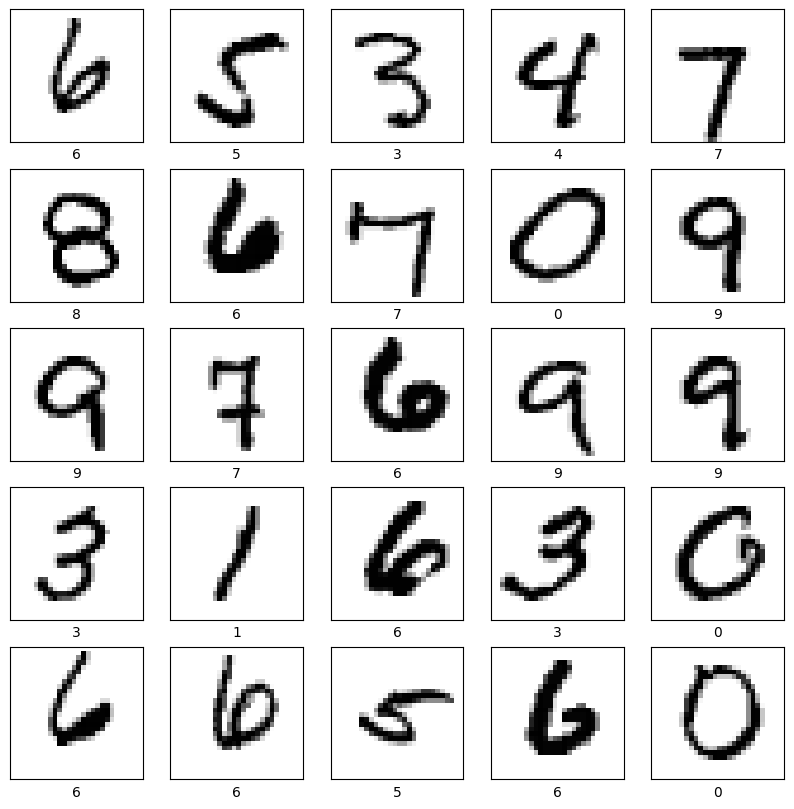

In [154]:
plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(x_train[i].reshape(28,28), cmap=plt.cm.binary)
    plt.xlabel(y_train[i])
plt.show()

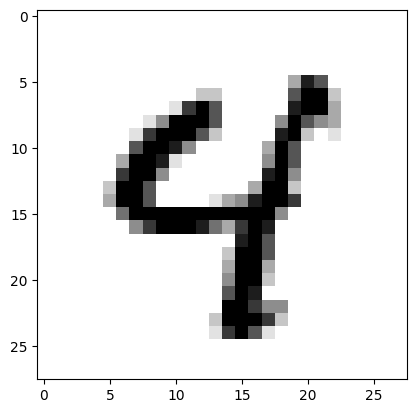

4


In [155]:
#Visualise Some Samples

def drawImg(sample):
  img = sample.reshape((28,28))
  plt.imshow(img, cmap=plt.cm.binary)
  plt.show()

drawImg(x_train[3])
print(y_train[3])

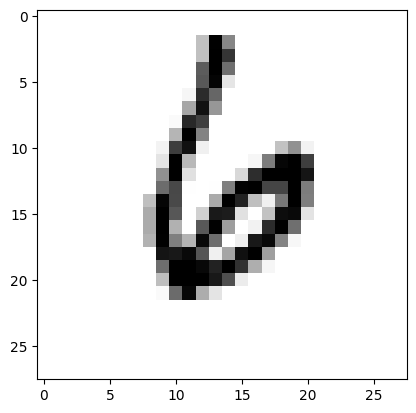

6


In [156]:
drawImg(x_train[0])
print(y_train[0])

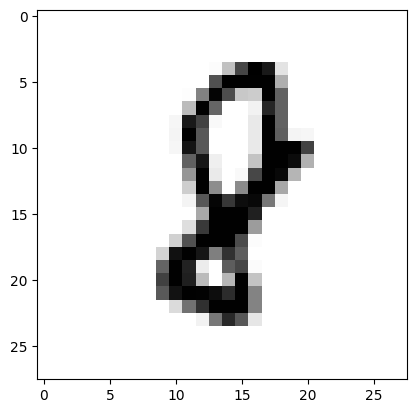

8


In [170]:
# Example usage with the original test data
index = 0  # Index of the sample you want to draw
drawImg(x_test[index])
print(y_test[index])

# **Feature Selection**

## **PCA**

In [96]:
#pca = PCA(n_components=50)
#X_train_pca = pca.fit_transform(x_train)
#X_test_pca = pca.transform(x_test)

## **LDA**

In [124]:
#lda = LDA(n_components=9)
#X_train_lda = lda.fit_transform(x_train, y_train)
#X_test_lda = lda.transform(x_test)

## **RandomForestClassifier**

In [178]:
clf = RandomForestClassifier(n_estimators=100)
clf.fit(x_train, y_train)

model = SelectFromModel(clf, prefit=True)
X_train_selected = model.transform(x_train)
X_test_selected = model.transform(x_test)

In [187]:
selected_columns_indices = np.where(model.get_support())[0]
print("Selected Column Indices:", selected_columns_indices)

Selected Column Indices: [ 99 100 101 124 125 126 127 150 151 152 153 154 155 156 157 158 159 176
 177 178 179 180 181 182 183 184 185 186 187 189 190 205 206 207 208 209
 210 211 212 213 214 215 216 217 218 233 234 235 236 237 238 239 240 241
 242 243 244 245 246 260 261 262 263 264 265 266 267 268 269 270 271 272
 273 288 289 290 291 292 293 294 295 296 297 298 299 300 301 316 317 318
 319 320 321 322 323 324 325 326 327 328 329 343 344 345 346 347 348 349
 350 351 352 353 354 355 356 357 358 359 371 372 373 374 375 376 377 378
 379 380 381 382 383 384 386 399 400 401 402 403 404 405 406 407 408 409
 410 411 413 414 427 428 429 430 431 432 433 434 435 436 437 438 439 440
 441 455 456 457 458 459 460 461 462 463 464 465 466 467 468 482 483 484
 485 486 487 488 489 490 491 492 493 494 495 510 511 512 513 514 515 516
 517 518 519 520 521 522 523 524 539 540 541 542 543 544 545 546 547 549
 550 551 566 567 568 569 570 571 572 573 574 575 576 577 578 579 595 596
 597 598 599 600 601 602 6

# **Clustering**

## **K-means Clustering**

In [158]:
kmeans = KMeans(n_clusters=10)
X_train_clusters = kmeans.fit_predict(X_train_selected)
X_test_clusters = kmeans.predict(X_test_selected)

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


# **KNN**

In [159]:
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train_selected, y_train)

KNeighborsClassifier(n_neighbors=3)

In [160]:
y_pred = knn.predict(X_test_selected)

In [161]:
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print(f'Accuracy: {accuracy}')

Accuracy: 0.9673809523809523


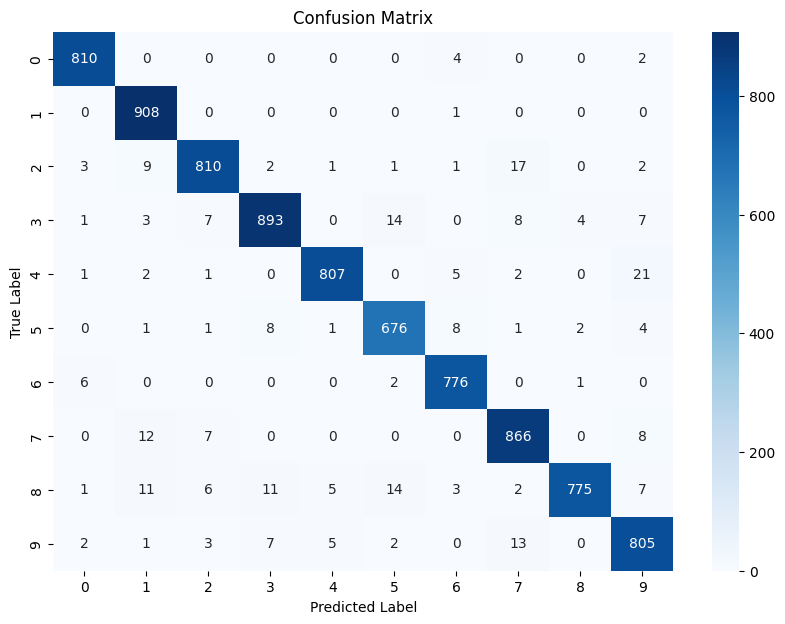

In [162]:
plt.figure(figsize=(10, 7))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=np.arange(10), yticklabels=np.arange(10))
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [163]:
class_report = classification_report(y_test, y_pred)
print('Classification Report:')
print(class_report)

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       816
           1       0.96      1.00      0.98       909
           2       0.97      0.96      0.96       846
           3       0.97      0.95      0.96       937
           4       0.99      0.96      0.97       839
           5       0.95      0.96      0.96       702
           6       0.97      0.99      0.98       785
           7       0.95      0.97      0.96       893
           8       0.99      0.93      0.96       835
           9       0.94      0.96      0.95       838

    accuracy                           0.97      8400
   macro avg       0.97      0.97      0.97      8400
weighted avg       0.97      0.97      0.97      8400



# **LogisticRegression**

In [164]:
from sklearn.linear_model import LogisticRegression
log_reg = LogisticRegression(max_iter=1000, solver='lbfgs', multi_class='multinomial')
log_reg.fit(X_train_selected, y_train)

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000, multi_class='multinomial')

In [165]:
accuracy = log_reg.score(X_test_selected, y_test)
print(f'Accuracy: {accuracy}')

Accuracy: 0.9021428571428571


# **GaussianNB**

In [166]:
from sklearn.naive_bayes import GaussianNB
gnb = GaussianNB()
gnb.fit(X_train_selected, y_train)

GaussianNB()

In [167]:
accuracy = gnb.score(X_test_selected, y_test)
print(f'Accuracy: {accuracy}')

Accuracy: 0.78


## **Test**

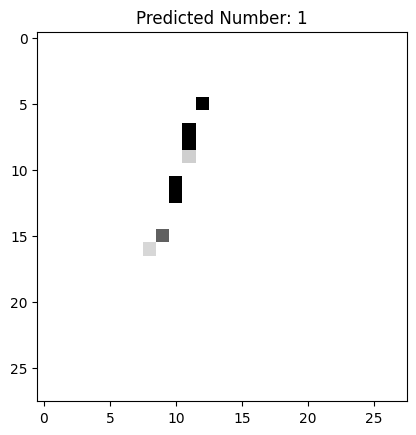

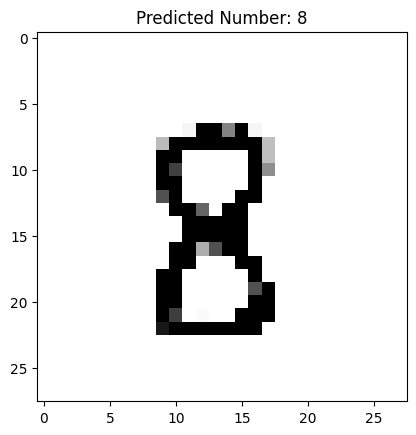

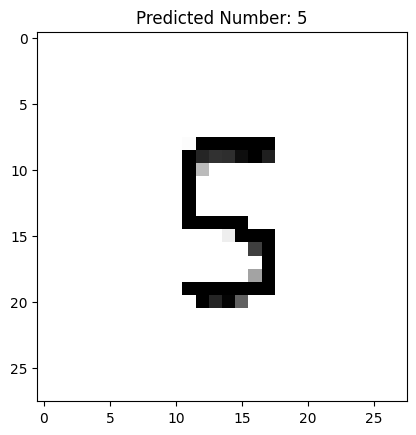

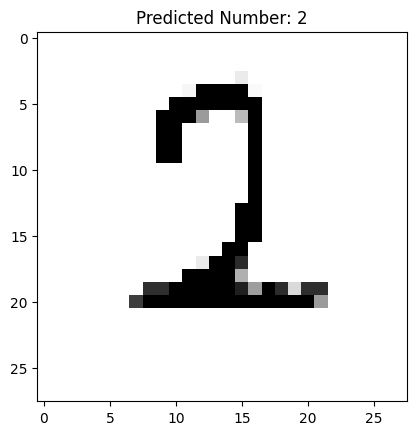

In [169]:
# Predict new images
for x in range(2, 6):
    img = cv.imread(f'{x}.png')[:, :, 0]
    img = np.invert(img)
    img_resized = cv.resize(img, (28, 28))
    img_flattened = img_resized.flatten()

    # Transform new image using the same feature selection model
    img_selected = model.transform([img_flattened])

    prediction = knn.predict(img_selected)
    plt.imshow(img_resized, cmap=plt.cm.binary)
    plt.title(f'Predicted Number: {prediction[0]}')
    plt.show()